In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


In [2]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
WB_key = user_secrets.get_secret("wandb-key")


In [3]:
import wandb
wandb.login(key = WB_key)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


True

In [4]:
import re
import string
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.feature_extraction.text import (
    ENGLISH_STOP_WORDS,
    TfidfVectorizer
)
from sklearn.metrics.pairwise import cosine_similarity

from gensim.models import Word2Vec

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

OPTION_LABELS = ["A", "B", "C", "D", "E"]
TEXT_COLUMNS = ["prompt", "A", "B", "C", "D", "E"]
ANSWER_COLUMN = "answer"

In [5]:
train = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv") 
test = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")
ss = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv")
train.head()

,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


In [6]:
train.shape

(2000, 8)

In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   prompt  2000 non-null   object
 2   A       2000 non-null   object
 3   B       2000 non-null   object
 4   C       2000 non-null   object
 5   D       2000 non-null   object
 6   E       2000 non-null   object
 7   answer  2000 non-null   object
dtypes: int64(1), object(7)
memory usage: 125.1+ KB


In [8]:
train.describe(include ="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,2000.0,NaN,NaN,NaN,1000.5,577.494589,1.0,500.75,1000.5,1500.25,2000.0
prompt,2000,1758,Select the most accurate option: How do the Lu...,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A,2000,316,An improper rotation is the combination of a r...,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
B,2000,328,An improper rotation is the combination of a r...,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
C,2000,303,An improper rotation is the combination of a r...,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
D,2000,318,An improper rotation is the combination of a r...,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
E,2000,320,An improper rotation is the combination of a r...,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
answer,2000,5,B,490,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
missing_values = train.isnull().sum()
missing_values

id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64

answer
A    369
B    490
C    459
D    358
E    324
Name: count, dtype: int64


<Axes: title={'center': 'Answer Distribution'}, xlabel='answer'>

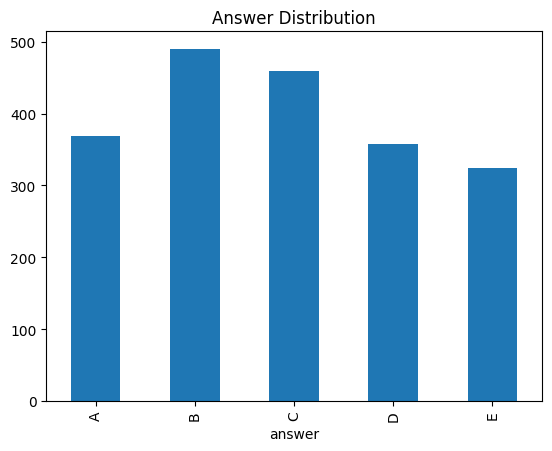

In [10]:
answer_distribution = (
    train["answer"]
    .value_counts()
    .sort_index()
)

print(answer_distribution)

answer_distribution.plot(
    kind="bar",
    title="Answer Distribution"
)

In [11]:
def clean_text(text):

    if pd.isna(text):
        return ""

    text = str(text)

    text = text.lower()

    text = text.replace("\n", " ")

    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()

In [12]:
for column in TEXT_COLUMNS:

    train[f"{column}_clean"] = (
        train[column]
        .apply(clean_text)
    )

In [13]:
train["prompt_tokens"] = (
    train["prompt_clean"]
    .str.split()
)

In [14]:
vocab = set()

for tokens in train["prompt_tokens"]:
    vocab.update(tokens)

print(
    "Vocabulary Size:",
    len(vocab)
)

Vocabulary Size: 859


In [15]:
sample_tokens = train.iloc[0]["prompt_tokens"]

filtered = [

    word

    for word in sample_tokens

    if word not in ENGLISH_STOP_WORDS

]

print(filtered)

['pick', 'best', 'possible', 'answer', 'martin', 'heideggers', 'view', 'relationship', 'time', 'human', 'existence', 'listed', 'options']


In [16]:
corpus = []

for col in [
    "prompt_clean",
    "A_clean",
    "B_clean",
    "C_clean",
    "D_clean",
    "E_clean"
]:

    corpus.extend(
        train[col].tolist()
    )

vectorizer = TfidfVectorizer(
    ngram_range=(1,2)
)

vectorizer.fit(corpus)

print(
    len(vectorizer.vocabulary_)
)

12811


In [17]:
from sklearn.metrics.pairwise import cosine_similarity

row = train.iloc[0]

prompt_vec = vectorizer.transform(
    [row["prompt_clean"]]
)

option_vecs = vectorizer.transform([

    row["A_clean"],
    row["B_clean"],
    row["C_clean"],
    row["D_clean"],
    row["E_clean"]

])

scores = cosine_similarity(
    prompt_vec,
    option_vecs
)[0]

scores

array([0.08631592, 0.09491449, 0.2292967 , 0.28242676, 0.04090108])

In [18]:
OPTION_LABELS = [
    "A",
    "B",
    "C",
    "D",
    "E"
]

predictions = []

for i, row in train.iterrows():

    prompt_vec = vectorizer.transform(
        [row["prompt_clean"]]
    )

    option_vecs = vectorizer.transform([

        row["A_clean"],
        row["B_clean"],
        row["C_clean"],
        row["D_clean"],
        row["E_clean"]

    ])

    sims = cosine_similarity(
        prompt_vec,
        option_vecs
    )[0]

    ranked = np.argsort(sims)[::-1]

    predictions.append(

        [

            OPTION_LABELS[i]

            for i in ranked[:3]

        ]

    )

In [19]:
def apk(actual, predicted):

    predicted = predicted[:3]

    if actual in predicted:

        return 1 / (
            predicted.index(actual)+1
        )

    return 0


def mapk(actuals, predictions):

    return np.mean(

        [

            apk(a,p)

            for a,p

            in zip(
                actuals,
                predictions
            )

        ]

    )

In [20]:
tfidf_score = mapk(
    train["answer"],
    predictions
)

print(tfidf_score)

0.2828333333333333


In [21]:
from gensim.models import Word2Vec
corpus = []

for col in [
    "prompt_clean",
    "A_clean",
    "B_clean",
    "C_clean",
    "D_clean",
    "E_clean"
]:
    corpus.extend(train[col].str.split().tolist())

word2vec_model = Word2Vec(
    sentences=corpus,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    seed=42
)


In [22]:
word2vec_predictions = []

for i, row in train.iterrows():

    prompt_tokens = row["prompt_clean"].split()

    prompt_vectors = [
        word2vec_model.wv[word]
        for word in prompt_tokens
        if word in word2vec_model.wv
    ]

    if len(prompt_vectors) == 0:
        prompt_embedding = np.zeros(word2vec_model.vector_size)
    else:
        prompt_embedding = np.mean(prompt_vectors, axis=0)

    similarities = []

    for option in ["A", "B", "C", "D", "E"]:

        option_tokens = row[f"{option}_clean"].split()

        option_vectors = [
            word2vec_model.wv[word]
            for word in option_tokens
            if word in word2vec_model.wv
        ]

        if len(option_vectors) == 0:
            option_embedding = np.zeros(word2vec_model.vector_size)
        else:
            option_embedding = np.mean(option_vectors, axis=0)

        if (
            np.linalg.norm(prompt_embedding) == 0
            or np.linalg.norm(option_embedding) == 0
        ):
            similarity = 0
        else:
            similarity = cosine_similarity(
                prompt_embedding.reshape(1, -1),
                option_embedding.reshape(1, -1)
            )[0][0]

        similarities.append((option, similarity))

    similarities.sort(
        key=lambda x: x[1],
        reverse=True
    )

    top3 = [option for option, _ in similarities[:3]]

    word2vec_predictions.append(top3)

In [23]:
word2vec_score = mapk(
    train["answer"],
    word2vec_predictions
)

print(f"Word2Vec MAP@3: {word2vec_score:.5f}")

Word2Vec MAP@3: 0.32783


In [24]:
results = pd.DataFrame({

    "Model":[

        "TF-IDF",
        "Word2Vec"

    ],

    "MAP@3":[

        tfidf_score,
        word2vec_score

    ]

})

results

,Model,MAP@3
0,TF-IDF,0.282833
1,Word2Vec,0.327833


In [25]:
errors = train[

    [

        actual not in pred

        for actual,pred

        in zip(

            train["answer"],
            predictions

        )

    ]

]

errors.head()

,id,prompt,A,B,C,D,E,answer,prompt_clean,A_clean,B_clean,C_clean,D_clean,E_clean,prompt_tokens
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A,identify the correct statement what is the con...,simultaneity is relative meaning that two even...,simultaneity is relative meaning that two even...,simultaneity is absolute meaning that two even...,simultaneity is a concept that applies only to...,simultaneity is a concept that applies only to...,"[identify, the, correct, statement, what, is, ..."
6,7,"Which of the following is correct? What is a ""...",A type of coffee that is made by boiling coffe...,A pattern left by a particle-laden liquid afte...,A type of coffee that is made by mixing instan...,A type of coffee that is made by pouring hot w...,A pattern left by a particle-laden liquid afte...,E,which of the following is correct what is a co...,a type of coffee that is made by boiling coffe...,a pattern left by a particleladen liquid after...,a type of coffee that is made by mixing instan...,a type of coffee that is made by pouring hot w...,a pattern left by a particleladen liquid after...,"[which, of, the, following, is, correct, what,..."
7,8,Select the most accurate option: What is the L...,The Liouville density is a probability distrib...,The Liouville density is a quasiprobability di...,The Liouville density is a bounded probability...,The Liouville density is a probability distrib...,The Liouville density is a probability distrib...,A,select the most accurate option what is the li...,the liouville density is a probability distrib...,the liouville density is a quasiprobability di...,the liouville density is a bounded probability...,the liouville density is a probability distrib...,the liouville density is a probability distrib...,"[select, the, most, accurate, option, what, is..."
8,9,Select the most accurate option: What are the ...,"They are unknown, but possibilities include la...",They are known to be black holes and Preon stars.,They are only MACHOs.,They are clusters of brown dwarfs.,They are new particles such as RAMBOs.,A,select the most accurate option what are the c...,they are unknown but possibilities include lar...,they are known to be black holes and preon stars,they are only machos,they are clusters of brown dwarfs,they are new particles such as rambos,"[select, the, most, accurate, option, what, ar..."
10,11,Select the most accurate option: What is the P...,The Peierls bracket is a mathematical symbol u...,The Peierls bracket is a mathematical tool use...,The Peierls bracket is a Poisson bracket deriv...,The Peierls bracket is a mathematical symbol u...,The Peierls bracket is a mathematical tool use...,C,select the most accurate option what is the pe...,the peierls bracket is a mathematical symbol u...,the peierls bracket is a mathematical tool use...,the peierls bracket is a poisson bracket deriv...,the peierls bracket is a mathematical symbol u...,the peierls bracket is a mathematical tool use...,"[select, the, most, accurate, option, what, is..."


# Milestone -02

In [31]:
from datasets import Dataset
from transformers import AutoTokenizer, AutoModel, pipeline

import torch

In [32]:
train["combined_text"] = (
    "Question:" + train["prompt"].astype(str)+
    "[SEP] A:" + train["A"].astype(str)+
    "[SEP] B: " + train["B"].astype(str) +
    "[SEP] C: " + train["C"].astype(str) +
    "[SEP] D: " + train["D"].astype(str) +
    "[SEP] E: " + train["E"].astype(str)
)

train["combined_text"].head()

0    Question:Pick the best possible answer: What i...
1    Question:What is accelerator-based light-ion f...
2    Question:Determine the correct option: What is...
3    Question:Select the most accurate option: What...
4    Question:Identify the correct statement: What ...
Name: combined_text, dtype: object

In [33]:
hf_dataset = Dataset.from_pandas(train)
print(hf_dataset)

Dataset({
    features: ['id', 'prompt', 'A', 'B', 'C', 'D', 'E', 'answer', 'prompt_clean', 'A_clean', 'B_clean', 'C_clean', 'D_clean', 'E_clean', 'prompt_tokens', 'combined_text'],
    num_rows: 2000
})


In [34]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [35]:
def tokenize_question(q_rec):
    return tokenizer(
        q_rec["combined_text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

tokenized_data = hf_dataset.map(tokenize_question)

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [36]:
print(type(tokenizer))

<class 'transformers.models.bert.tokenization_bert.BertTokenizer'>


In [40]:
bert_model = AutoModel.from_pretrained("bert-base-uncased")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [41]:
sample_text = train.loc[0, "combined_text"]

encoded_input = tokenizer(
    sample_text,
    return_tensors="pt",
    truncation = True,
    padding = True,
    max_length = 128
)

with torch.no_grad():
    model_output = bert_model(**encoded_input)

In [42]:
print(model_output.last_hidden_state.shape)

torch.Size([1, 128, 768])


In [43]:
cls_embd = model_output.last_hidden_state[:, 0, :]
print(cls_embd.shape)

torch.Size([1, 768])


In [44]:
print(cls_embd)

tensor([[-7.4148e-01, -2.4751e-01, -4.6052e-01,  6.6293e-02, -4.7507e-01,
         -2.7829e-01, -8.5259e-03,  7.1193e-01,  2.3093e-02, -4.8834e-01,
          4.1907e-01, -2.9360e-01, -7.1969e-01,  5.6539e-01,  2.8380e-01,
          2.2243e-01,  2.6722e-01,  1.2933e-01, -5.1242e-02, -1.5230e-01,
          3.8877e-01,  1.0984e-01,  5.4504e-02,  1.5385e-01,  2.7088e-01,
         -2.1820e-01, -2.5846e-01, -3.5142e-01, -1.4610e-01,  1.9758e-01,
         -5.2337e-01,  2.3074e-01, -7.0740e-01, -7.9952e-01,  4.4897e-01,
         -2.1518e-01, -4.5176e-02, -1.0546e-01,  3.0946e-01,  1.2587e-02,
         -3.4917e-01,  2.9873e-01,  3.0974e-02,  3.7610e-02, -6.6800e-02,
         -2.3308e-01, -3.8073e+00, -3.8198e-01, -3.5585e-01, -2.9616e-01,
         -4.3169e-01, -1.3655e-01,  4.4189e-01,  1.1930e+00,  2.5374e-01,
          4.5438e-01, -6.5639e-01,  6.4554e-02, -1.0157e-01, -2.1920e-01,
          5.3447e-01,  2.2536e-01, -1.5668e-01, -5.5367e-01, -1.2978e-01,
          5.2394e-01,  2.4667e-01,  3.

In [49]:
zero_shot_classifier= pipeline(
    "zero-shot-classification",
    model = "facebook/bart-large-mnli"
)

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

In [51]:
sample_ques = train.loc[0, "prompt"]
print(sample_ques)

Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.


In [56]:
candidate_lbls = [
    "Science",
    "Mathematics",
    "History",
    "Geography",
    "Technology"
]

In [58]:
pred= zero_shot_classifier(
    sample_ques,
    candidate_lbls
)
pred

{'sequence': "Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.",
 'labels': ['History', 'Technology', 'Science', 'Mathematics', 'Geography'],
 'scores': [0.2916789948940277,
  0.23507289588451385,
  0.2320403903722763,
  0.12123064696788788,
  0.11997699737548828]}

In [59]:
print("Predicted Labels:")
print(pred["labels"])

print("\nConfidence Scores:")
print(pred["scores"])

Predicted Labels:
['History', 'Technology', 'Science', 'Mathematics', 'Geography']

Confidence Scores:
[0.2916789948940277, 0.23507289588451385, 0.2320403903722763, 0.12123064696788788, 0.11997699737548828]


In [61]:
print("Most Likely Category:", pred["labels"][0])
print("Confidence Score:", round(pred["scores"][0], 4))

Most Likely Category: History
Confidence Score: 0.2917
